## Los influencer digitales y el marketing de productos típicos regionales. El caso del Bacanora.

**OBJETIVO GENERAL:**

Explicar cómo y por qué un influencer logra modificar la actitud, el engagement y la intención de compra de un seguidor, cuando promueve un producto regional sensible como el bacanora.

### PASO 1. Validación de Constructos de PRIMER ORDEN

| Criterio                                      | Qué responde                                                 | ¿Se realizó? | Evidencia en el estudio                   | Justificación / observación                                             |
| --------------------------------------------- | ------------------------------------------------------------ | ------------ | ----------------------------------------- | ----------------------------------------------------------------------- |
| Alfa de Cronbach                              | ¿Los ítems son consistentes entre sí?                        | Sí           | Todos los constructos presentan α ≥ 0.80  | Cumple el criterio de fiabilidad interna recomendado (α ≥ 0.70).        |
| Fiabilidad compuesta (CR)                     | ¿El constructo es confiable como variable latente?           | Sí           | Todos los constructos presentan CR ≥ 0.81 | Indicador preferido en SEM; confirma estabilidad del constructo.        |
| Cargas factoriales                            | ¿Cada ítem mide adecuadamente su constructo?                 | Sí           | Todas las cargas absolutas ≥ 0.64         | Los valores superan el umbral mínimo aceptable para estudios aplicados. |
| Varianza media extraída (AVE)                 | ¿El constructo explica la varianza de sus ítems?             | Sí           | AVE ≥ 0.50 en todos los constructos       | Confirma validez convergente según el criterio de Fornell y Larcker.    |
| Validez convergente (global)                  | ¿Los ítems convergen en un mismo concepto?                   | Sí           | Cargas altas + AVE adecuada               | Evidencia conjunta de convergencia psicométrica.                        |
| Validez discriminante (HTMT)                  | ¿Los constructos son empíricamente distintos entre sí?       | Sí           | HTMT calculado para todos los pares       | Método recomendado actualmente sobre Fornell–Larcker.                   |
| Fornell–Larcker                               | ¿La varianza del constructo supera su correlación con otros? | No           | No reportado                              | No es obligatorio cuando se utiliza HTMT como criterio principal.       |
| Omega (ω)                                     | ¿Confiabilidad ajustada al error factorial?                  | No           | No calculado                              | α y CR son suficientes; ω es recomendable pero no obligatorio.          |
| CFA global (CFI, RMSEA, SRMR)                 | ¿El modelo de medición presenta buen ajuste global?          | No           | No estimado                               | No requerido en PLS-SEM; se omite por coherencia metodológica.          |
| Sesgo de método común (CLF / marker)          | ¿Existe varianza atribuible al método?                       | No           | No evaluado en esta fase                  | Puede abordarse posteriormente o declararse como limitación.            |
| Re-especificación por índices de modificación | ¿Se mejoró el ajuste ajustando el modelo?                    | No           | No aplicable                              | No procede al no utilizar CFA basada en covarianzas.                    |



#### A. Factor Analyzer

In [ ]:
%%capture
!pip install factor_analyzer

In [ ]:
constructos = {
    'integridad': ['int_1', 'int_2', 'int_3', 'int_4'],
    'expertis': ['exp_1', 'exp_2', 'exp_3', 'exp_4'],
    'autenticidad': ['aut_1', 'aut_2', 'aut_3'],
    'atractividad': ['att_1', 'att_2', 'att_3', 'att_4'],
    'similitud': ['sim_1', 'sim_2', 'sim_3'],
    'lider_de_opinion': ['lid_1', 'lid_2', 'lid_3', 'lid_4'],
    'informatividad_del_contenido': ['inf_1', 'inf_2', 'inf_3'],
    'congruencia_influencer_follower': ['congf_1', 'congf_2', 'congf_3'],
    'congruencia_influencer_producto': ['congp_1', 'congp_2', 'congp_3'],
    'conciencia_de_la_persuasion': ['concp_1', 'concp_2', 'concp_3', 'concp_4', 'concp_5'],
    'actitud': ['act_1', 'act_2', 'act_3'],
    'predisposicion_a_comprar_un_producto': ['pred_1', 'pred_2', 'pred_3'],
    'engagement': ['eng_1', 'eng_2', 'eng_3', 'eng_4', 'eng_5']
}

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
import warnings
warnings.filterwarnings("ignore")

# cargar datos
data = pd.read_excel("/content/drive/MyDrive/0. B/2024/MLE/Proyectos Activos 2024/1. Beatriz - Bacanora/Entregables/1. Entregables Final 2026/Entregables FINAL/datos_codificados_ajustados.xlsx")

def cronbach_alpha(df):
    df = df.dropna()
    k = df.shape[1]
    variances = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - variances.sum() / total_var)
    return alpha

def factor_loadings(df):
    df = df.dropna()
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(df)
    loadings = np.abs(fa.loadings_.flatten())
    return loadings

def ave_cr(loadings):
    loadings_sq = loadings ** 2
    ave = loadings_sq.mean()
    cr = (loadings.sum() ** 2) / ((loadings.sum() ** 2) + ((1 - loadings_sq).sum()))
    return ave, cr

resultados = []

for constructo, items in constructos.items():
    df_items = data[items]

    alpha = cronbach_alpha(df_items)
    loadings = factor_loadings(df_items)
    ave, cr = ave_cr(loadings)

    resultados.append({
        'Constructo': constructo,
        'Alpha': round(alpha, 3),
        'CR': round(cr, 3),
        'AVE': round(ave, 3),
        'Carga_min': round(loadings.min(), 3),
        'Carga_max': round(loadings.max(), 3)
    })

resultados_df = pd.DataFrame(resultados)
resultados_df


,Constructo,Alpha,CR,AVE,Carga_min,Carga_max
0,integridad,0.825,0.826,0.542,0.693,0.781
1,expertis,0.848,0.849,0.586,0.717,0.840
2,autenticidad,0.816,0.816,0.596,0.756,0.782
3,atractividad,0.858,0.859,0.603,0.757,0.794
4,similitud,0.781,0.782,0.544,0.717,0.748
5,lider_de_opinion,0.867,0.867,0.620,0.755,0.811
6,informatividad_del_contenido,0.814,0.814,0.593,0.765,0.777
7,congruencia_influencer_follower,0.784,0.785,0.550,0.708,0.794
8,congruencia_influencer_producto,0.794,0.794,0.563,0.723,0.773
9,conciencia_de_la_persuasion,0.869,0.870,0.572,0.701,0.786


**Interpretación:**

1. Integridad: El constructo integridad presentó una adecuada confiabilidad interna (α = 0.825; CR = 0.826) y una varianza media extraída de 0.542, superior al umbral mínimo recomendado. En conjunto, los resultados muestran que los ítems miden de forma consistente la percepción de honestidad y confiabilidad del influencer.

2. Expertis: El constructo expertis mostró niveles aceptables de confiabilidad (α = 0.848; CR = 0.849) y una AVE de 0.586, superior al umbral recomendado. Estos resultados indican que los ítems utilizados miden adecuadamente la percepción de conocimiento y experiencia del influencer respecto al producto promocionado.

3. Autenticidad: El constructo autenticidad presentó una adecuada consistencia interna (α = 0.816; CR = 0.816) y una validez convergente satisfactoria (AVE = 0.596). Por lo tanto, se considera que los ítems representan de manera adecuada la percepción de sinceridad y dedicación del influencer.

4. Atractividad: El constructo atractividad evidenció una elevada confiabilidad (α = 0.858; CR = 0.859) y una AVE de 0.603, lo que confirma que los ítems utilizados miden de forma consistente la percepción de atractivo físico y estilo del influencer.

5. Similitud: El constructo similitud presentó niveles adecuados de confiabilidad (α = 0.781; CR = 0.782) y una AVE de 0.544. Esto indica que los ítems representan adecuadamente el grado de identificación percibida entre el seguidor y el influencer.

6. Liderazgo de opinión: El constructo liderazgo de opinión mostró los niveles más altos de confiabilidad del bloque (α = 0.867; CR = 0.867) y una AVE de 0.620. En consecuencia, los ítems utilizados miden de forma consistente la percepción del influencer como referente y fuente de influencia social.

7. Informatividad del contenido: El constructo informatividad del contenido presentó una confiabilidad adecuada (α = 0.814; CR = 0.814) y una AVE de 0.593. Estos resultados indican que los ítems miden correctamente la utilidad y relevancia de la información compartida por el influencer.

8. Congruencia influencer–seguidor: El constructo congruencia influencer–seguidor mostró niveles satisfactorios de confiabilidad (α = 0.784; CR = 0.785) y una AVE de 0.550. Esto sugiere que los ítems representan adecuadamente la percepción de compatibilidad entre el influencer y el seguidor.

9. Congruencia influencer–producto: El constructo congruencia influencer–producto presentó una confiabilidad interna adecuada (α = 0.794; CR = 0.794) y una AVE de 0.563, lo que indica una correcta medición de la coherencia percibida entre el influencer y el producto promocionado.

10. Conciencia de la persuasión: El constructo conciencia de la persuasión evidenció la confiabilidad más alta del modelo (α = 0.869; CR = 0.870) y una AVE de 0.572. Estos resultados confirman que los ítems miden de manera adecuada el reconocimiento de la intención persuasiva del influencer.

11. Actitud: El constructo actitud presentó niveles adecuados de confiabilidad (α = 0.791; CR = 0.792) y una AVE de 0.560. En consecuencia, los ítems utilizados representan correctamente la evaluación afectiva del seguidor hacia el bacanora.

12. Predisposición a comprar el producto: El constructo predisposición a comprar el producto mostró una consistencia interna adecuada (α = 0.799; CR = 0.799) y una AVE de 0.570. Esto indica que los ítems miden de forma consistente la intención de compra declarada por el seguidor.

13. Engagement: El constructo engagement presentó niveles aceptables de confiabilidad (α = 0.840; CR = 0.841) y una AVE de 0.514, ligeramente superior al valor mínimo recomendado. Las cargas factoriales oscilaron entre 0.674 y 0.775, lo que confirma la convergencia adecuada de los ítems. Aunque este constructo muestra los valores de AVE más ajustados del modelo, cumple con los criterios establecidos, por lo que se considera adecuadamente operacionalizado.

#### B. Validez discriminante (HTMT)

In [ ]:
items = [item for sublist in constructos.values() for item in sublist]
data_items = data[items].apply(pd.to_numeric, errors='coerce')

def htmt_matrix(data, constructos):
    corr = data.corr().abs()
    names = list(constructos.keys())
    htmt = pd.DataFrame(index=names, columns=names, dtype=float)

    for i, ci in enumerate(names):
        for j, cj in enumerate(names):
            if i == j:
                htmt.loc[ci, cj] = 1.0
            elif i < j:
                items_i = constructos[ci]
                items_j = constructos[cj]

                het = corr.loc[items_i, items_j].values.flatten().mean()
                mono_i = corr.loc[items_i, items_i].values[np.triu_indices(len(items_i), 1)].mean()
                mono_j = corr.loc[items_j, items_j].values[np.triu_indices(len(items_j), 1)].mean()

                value = het / np.sqrt(mono_i * mono_j)
                htmt.loc[ci, cj] = value
                htmt.loc[cj, ci] = value

    return htmt

htmt_df = htmt_matrix(data_items, constructos)
htmt_df


,integridad,expertis,autenticidad,atractividad,similitud,lider_de_opinion,informatividad_del_contenido,congruencia_influencer_follower,congruencia_influencer_producto,conciencia_de_la_persuasion,actitud,predisposicion_a_comprar_un_producto,engagement
integridad,1.000000,0.156461,0.120030,0.079642,0.073390,0.102154,0.066217,0.118901,0.113906,0.075382,0.226304,0.088853,0.091757
expertis,0.156461,1.000000,0.101195,0.051974,0.083326,0.116461,0.073807,0.204041,0.100475,0.090895,0.209923,0.065427,0.213924
autenticidad,0.120030,0.101195,1.000000,0.087088,0.058672,0.113302,0.075577,0.146554,0.053666,0.102058,0.199782,0.068653,0.096872
atractividad,0.079642,0.051974,0.087088,1.000000,0.055586,0.097910,0.092021,0.070633,0.033685,0.079973,0.152319,0.065331,0.082723
similitud,0.073390,0.083326,0.058672,0.055586,1.000000,0.068087,0.054362,0.094746,0.085765,0.169743,0.193319,0.101490,0.155779
lider_de_opinion,0.102154,0.116461,0.113302,0.097910,0.068087,1.000000,0.175708,0.095000,0.043704,0.107864,0.123791,0.062651,0.049018
informatividad_del_contenido,0.066217,0.073807,0.075577,0.092021,0.054362,0.175708,1.000000,0.074083,0.121859,0.086060,0.119127,0.060233,0.101979
congruencia_influencer_follower,0.118901,0.204041,0.146554,0.070633,0.094746,0.095000,0.074083,1.000000,0.073886,0.077400,0.101008,0.076630,0.098879
congruencia_influencer_producto,0.113906,0.100475,0.053666,0.033685,0.085765,0.043704,0.121859,0.073886,1.000000,0.088754,0.104319,0.099120,0.105708
conciencia_de_la_persuasion,0.075382,0.090895,0.102058,0.079973,0.169743,0.107864,0.086060,0.077400,0.088754,1.000000,0.255746,0.147570,0.104937


**Interpretación: Validez discriminante (HTMT)**

La validez discriminante de los constructos fue evaluada mediante el criterio HTMT. Los resultados muestran que todos los valores fuera de la diagonal se encuentran muy por debajo del umbral recomendado (HTMT < 0.85), lo que confirma que los constructos son empíricamente distinguibles entre sí y que la validez discriminante del instrumento queda confirmada.

### PASO 2: Modelo estructural y prueba de hipótesis con SEM

**Propuesta de hipótesis del modelo estructural**

El modelo estructural se especifica con constructos de segundo orden como predictores directos de la actitud. Cada constructo de segundo orden agrega las dimensiones de primer orden mediante promedio simple, siguiendo el enfoque de dos etapas (two-stage approach) recomendado en la literatura de PLS-SEM aplicado a constructos jerárquicos. Este enfoque reduce la multicolinealidad entre predictores y otorga mayor potencia estadística a las pruebas de hipótesis.

**Bloque A. Características del influencer → Actitud**

- H1. La credibilidad percibida del influencer —integrada por su integridad, expertis y autenticidad— tiene un efecto positivo y significativo sobre la actitud del seguidor hacia el bacanora.
- H2. La semejanza percibida con el influencer —compuesta por su atractividad, similitud y liderazgo de opinión— tiene un efecto positivo y significativo sobre la actitud del seguidor hacia el bacanora.

**Bloque B. Contenido y congruencia → Actitud**

- H3. La informatividad del contenido compartido por el influencer influye positiva y significativamente en la actitud del seguidor hacia el bacanora.
- H4. La congruencia percibida —entre el influencer y el seguidor, y entre el influencer y el producto— tiene un efecto positivo y significativo sobre la actitud hacia el bacanora.

**Bloque C. Conciencia de la persuasión → Actitud**

- H5. La conciencia de la persuasión tiene un efecto negativo y significativo sobre la actitud del seguidor hacia el bacanora, atenuando la influencia del contenido del influencer.

**Bloque D. Actitud → Resultados conductuales**

- H6. La actitud positiva hacia el bacanora influye positiva y significativamente en el engagement del seguidor con el contenido del influencer.
- H7. La actitud hacia el bacanora influye positiva y significativamente en la predisposición a comprar el producto.
- H8. El engagement del seguidor influye positiva y significativamente en la predisposición a comprar el bacanora.

Estas ocho hipótesis conforman un modelo de ecuaciones estructurales completo que permite identificar qué dimensiones del influencer son estadísticamente relevantes en el contexto de productos regionales con identidad cultural, respondiendo directamente al objetivo general del estudio.

In [ ]:
%%capture
!pip -q install semopy openpyxl

N observaciones: 240

Correlaciones con actitud:
credibilidad             0.330
semejanza                0.225
informatividad           0.096
congruencia              0.110
conciencia_persuasion   -0.212
engagement               0.325
predisposicion           0.324
Name: actitud, dtype: float64

=== COEFICIENTES ESTRUCTURALES ===


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,actitud,~,credibilidad,0.658543,0.110007,5.986362,2.145868e-09
1,actitud,~,semejanza,0.401946,0.100417,4.002765,6.260647e-05
2,actitud,~,informatividad,0.093604,0.055861,1.675650,9.380677e-02
3,actitud,~,congruencia,0.201665,0.081072,2.487466,1.286569e-02
4,actitud,~,conciencia_persuasion,-0.231858,0.058574,-3.958386,7.545779e-05
5,engagement,~,actitud,0.302705,0.056752,5.333841,9.615684e-08
6,predisposicion,~,actitud,0.260791,0.063655,4.096966,4.186004e-05
7,predisposicion,~,engagement,0.214770,0.068457,3.137301,1.705111e-03



=== INDICES DE AJUSTE ===


,Valor



Ejecutando bootstrap (5000 replicas)...

=== INTERVALOS DE CONFIANZA BOOTSTRAP 95% ===


,Estimado,IC 2.5%,IC 97.5%,Significativo
path,,,,
actitud ~ conciencia_persuasion,-0.232083,-0.338019,-0.127011,Si
actitud ~ congruencia,0.203015,0.048497,0.355724,Si
actitud ~ credibilidad,0.661038,0.435262,0.878757,Si
actitud ~ informatividad,0.094323,-0.009981,0.200416,No
actitud ~ semejanza,0.403983,0.206202,0.597952,Si
engagement ~ actitud,0.302714,0.193066,0.410412,Si
predisposicion ~ actitud,0.259629,0.146159,0.369627,Si
predisposicion ~ engagement,0.215057,0.085437,0.341514,Si



=== EFECTO INDIRECTO: Actitud -> Engagement -> Predisposicion ===


,Efecto indirecto (media),IC 2.5%,IC 97.5%,Significativo
0,0.0651,0.024,0.1158,Si



=== RESUMEN DE HIPOTESIS ===


,Hipotesis,Ruta,Estimado,IC 2.5%,IC 97.5%,Significativo,Resultado
0,H1,credibilidad -> actitud,0.661,0.435,0.879,Si,Soportada
1,H2,semejanza -> actitud,0.404,0.206,0.598,Si,Soportada
2,H3,informatividad -> actitud,0.094,-0.010,0.200,No,No soportada
3,H4,congruencia -> actitud,0.203,0.048,0.356,Si,Soportada
4,H5,conciencia_persuasion -> actitud,-0.232,-0.338,-0.127,Si,Soportada
5,H6,actitud -> engagement,0.303,0.193,0.410,Si,Soportada
6,H7,actitud -> predisposicion,0.260,0.146,0.370,Si,Soportada
7,H8,engagement -> predisposicion,0.215,0.085,0.342,Si,Soportada


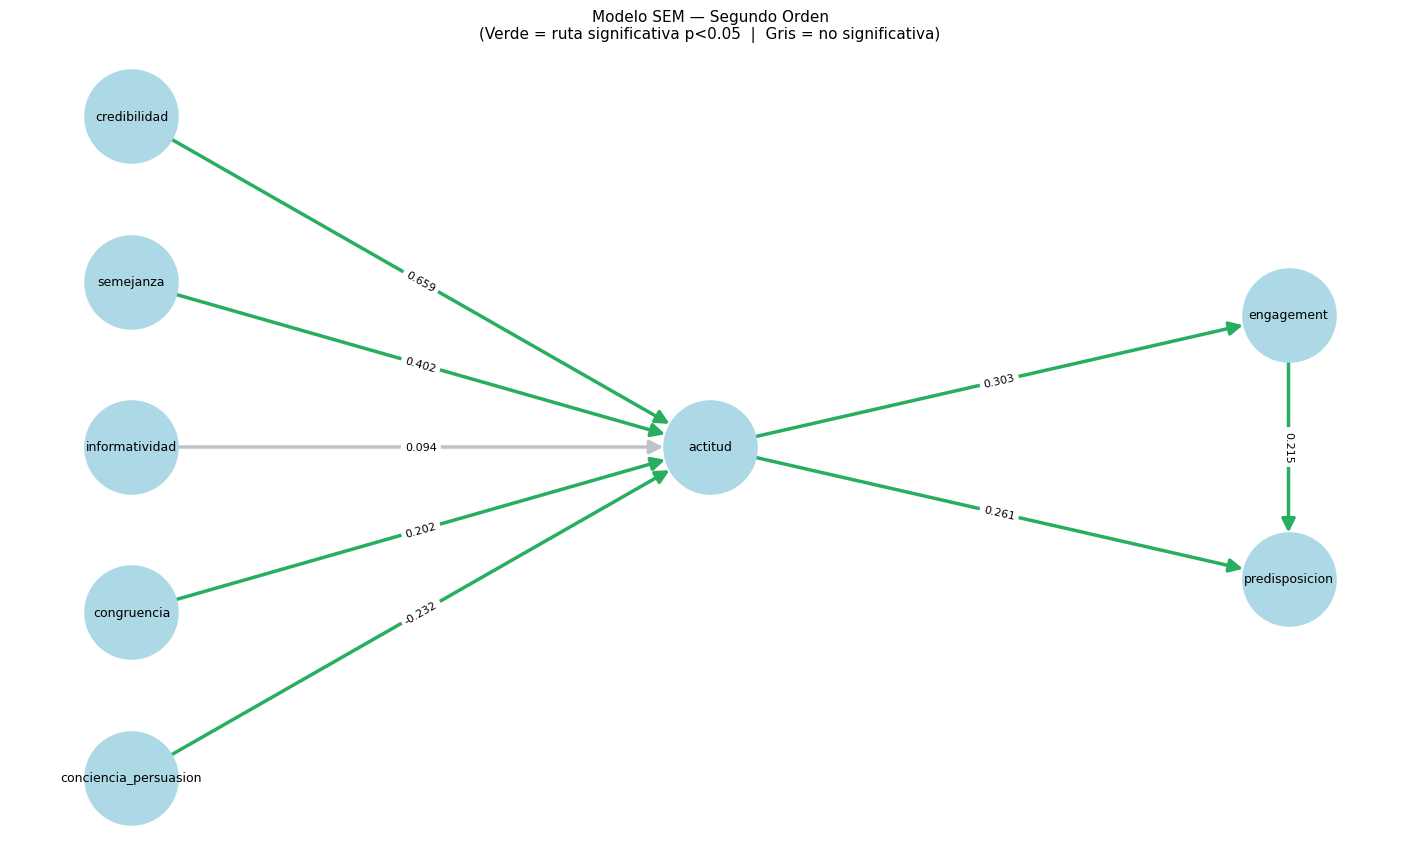

In [ ]:
import pandas as pd
import numpy as np
from semopy import Model
from semopy.stats import calc_stats
from IPython.display import display
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# CARGAR DATOS
# =========================================================

data = pd.read_excel("/content/drive/MyDrive/0. B/2024/MLE/Proyectos Activos 2024/1. Beatriz - Bacanora/Entregables/1. Entregables Final 2026/Entregables FINAL/datos_codificados_ajustados.xlsx")

# =========================================================
# CONSTRUCTOS DE PRIMER ORDEN
# =========================================================

constructos_1er = {
    "integridad":            ["int_1",   "int_2",   "int_3",   "int_4"],
    "expertis":              ["exp_1",   "exp_2",   "exp_3",   "exp_4"],
    "autenticidad":          ["aut_1",   "aut_2",   "aut_3"],
    "atractividad":          ["att_1",   "att_2",   "att_3",   "att_4"],
    "similitud":             ["sim_1",   "sim_2",   "sim_3"],
    "lider_de_opinion":      ["lid_1",   "lid_2",   "lid_3",   "lid_4"],
    "informatividad":        ["inf_1",   "inf_2",   "inf_3"],
    "cong_follower":         ["congf_1", "congf_2", "congf_3"],
    "cong_producto":         ["congp_1", "congp_2", "congp_3"],
    "conciencia_persuasion": ["concp_1", "concp_2", "concp_3", "concp_4", "concp_5"],
    "actitud":               ["act_1",   "act_2",   "act_3"],
    "engagement":            ["eng_1",   "eng_2",   "eng_3",   "eng_4",   "eng_5"],
    "predisposicion":        ["pred_1",  "pred_2",  "pred_3"],
}

# =========================================================
# SCORES DE PRIMER ORDEN
# =========================================================

scores = pd.DataFrame(index=data.index)
for nombre, items in constructos_1er.items():
    cols = [c for c in items if c in data.columns]
    scores[nombre] = data[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# =========================================================
# CONSTRUCTOS DE SEGUNDO ORDEN (promedios de primer orden)
# =========================================================

scores["credibilidad"]  = scores[["integridad", "expertis", "autenticidad"]].mean(axis=1)
scores["semejanza"]     = scores[["atractividad", "similitud", "lider_de_opinion"]].mean(axis=1)
scores["congruencia"]   = scores[["cong_follower", "cong_producto"]].mean(axis=1)

# =========================================================
# DATAFRAME FINAL
# =========================================================

model_df = scores[[
    "credibilidad",
    "semejanza",
    "informatividad",
    "congruencia",
    "conciencia_persuasion",
    "actitud",
    "engagement",
    "predisposicion",
]].dropna()

print(f"N observaciones: {len(model_df)}")

print("\nCorrelaciones con actitud:")
print(model_df.corr()["actitud"].drop("actitud").round(3))

# =========================================================
# ESPECIFICACIÓN DEL MODELO SEM
# =========================================================

desc = """
actitud        ~ credibilidad + semejanza + informatividad + congruencia + conciencia_persuasion
engagement     ~ actitud
predisposicion ~ actitud + engagement
"""

# =========================================================
# AJUSTE DEL MODELO
# =========================================================

mod = Model(desc)
mod.fit(model_df)

# =========================================================
# COEFICIENTES ESTRUCTURALES
# =========================================================

est = mod.inspect()
paths = est[est["op"] == "~"][[
    "lval", "op", "rval", "Estimate", "Std. Err", "z-value", "p-value"
]].copy().reset_index(drop=True)

print("\n=== COEFICIENTES ESTRUCTURALES ===")
display(paths)

# =========================================================
# INDICES DE AJUSTE
# =========================================================

stats = calc_stats(mod)
keys_interes = ["DoF", "chi2", "chi2 p-value", "CFI", "TLI", "RMSEA", "SRMR", "AIC", "BIC"]
stats_out = {k: stats[k] for k in keys_interes if k in stats}

print("\n=== INDICES DE AJUSTE ===")
display(pd.DataFrame.from_dict(stats_out, orient="index", columns=["Valor"]))

# =========================================================
# R²
# =========================================================

if "r2" in stats:
    print("\n=== R² POR VARIABLE ENDOGENA ===")
    display(stats["r2"])

# =========================================================
# BOOTSTRAP 5000 REPLICAS
# =========================================================

def bootstrap_paths(model_desc, df, n_boot=5000, seed=42):
    rng_b = np.random.default_rng(seed)
    coefs = []
    for _ in range(n_boot):
        idx = rng_b.integers(0, len(df), len(df))
        boot_df = df.iloc[idx].reset_index(drop=True)
        m = Model(model_desc)
        try:
            m.fit(boot_df)
            ins = m.inspect()
            p = ins[ins["op"] == "~"][["lval", "rval", "Estimate"]].copy()
            p["path"] = p["lval"] + " ~ " + p["rval"]
            coefs.append(p.set_index("path")["Estimate"])
        except Exception:
            continue
    return pd.DataFrame(coefs)

print("\nEjecutando bootstrap (5000 replicas)...")
boot = bootstrap_paths(desc, model_df, n_boot=5000, seed=42)

ci = pd.DataFrame({
    "Estimado": boot.mean(),
    "IC 2.5%":  boot.quantile(0.025),
    "IC 97.5%": boot.quantile(0.975),
    "Significativo": boot.apply(
        lambda col: "Si" if (
            col.quantile(0.025) > 0 or col.quantile(0.975) < 0
        ) else "No"
    )
}).sort_index()

print("\n=== INTERVALOS DE CONFIANZA BOOTSTRAP 95% ===")
display(ci)

# =========================================================
# EFECTO INDIRECTO: ACTITUD -> ENGAGEMENT -> PREDISPOSICION
# =========================================================

if "engagement ~ actitud" in boot.columns and "predisposicion ~ engagement" in boot.columns:
    boot_indirect = boot["engagement ~ actitud"] * boot["predisposicion ~ engagement"]
    indirect_ci = pd.DataFrame([{
        "Efecto indirecto (media)": round(boot_indirect.mean(), 4),
        "IC 2.5%":                  round(float(np.quantile(boot_indirect, 0.025)), 4),
        "IC 97.5%":                 round(float(np.quantile(boot_indirect, 0.975)), 4),
        "Significativo":            "Si" if np.quantile(boot_indirect, 0.025) > 0 else "No"
    }])
    print("\n=== EFECTO INDIRECTO: Actitud -> Engagement -> Predisposicion ===")
    display(indirect_ci)

# =========================================================
# TABLA RESUMEN DE HIPOTESIS
# =========================================================

hipotesis = {
    "H1": ("credibilidad",         "actitud",        "positivo"),
    "H2": ("semejanza",            "actitud",        "positivo"),
    "H3": ("informatividad",       "actitud",        "positivo"),
    "H4": ("congruencia",          "actitud",        "positivo"),
    "H5": ("conciencia_persuasion","actitud",        "negativo"),
    "H6": ("actitud",              "engagement",     "positivo"),
    "H7": ("actitud",              "predisposicion", "positivo"),
    "H8": ("engagement",           "predisposicion", "positivo"),
}

filas = []
for h, (rval, lval, direccion) in hipotesis.items():
    path_key = f"{lval} ~ {rval}"
    if path_key in ci.index:
        est_val  = round(ci.loc[path_key, "Estimado"], 3)
        ic_low   = round(ci.loc[path_key, "IC 2.5%"],  3)
        ic_high  = round(ci.loc[path_key, "IC 97.5%"], 3)
        sig      = ci.loc[path_key, "Significativo"]
        signo_ok = (direccion == "positivo" and est_val > 0) or \
                   (direccion == "negativo" and est_val < 0)
        soporte  = "Soportada" if sig == "Si" and signo_ok else "No soportada"
    else:
        est_val = ic_low = ic_high = "-"
        soporte = "No disponible"

    filas.append({
        "Hipotesis": h,
        "Ruta":      f"{rval} -> {lval}",
        "Estimado":  est_val,
        "IC 2.5%":   ic_low,
        "IC 97.5%":  ic_high,
        "Significativo": sig if path_key in ci.index else "-",
        "Resultado": soporte,
    })

resumen = pd.DataFrame(filas)
print("\n=== RESUMEN DE HIPOTESIS ===")
display(resumen)

# =========================================================
# DIAGRAMA DEL MODELO
# =========================================================

paths_sig = ci[ci["Significativo"] == "Si"].index.tolist()

G = nx.DiGraph()
for _, row in paths.iterrows():
    path_key = f"{row['lval']} ~ {row['rval']}"
    G.add_edge(
        row["rval"], row["lval"],
        weight=round(row["Estimate"], 3),
        sig="Si" if path_key in paths_sig else "No"
    )

pos = {
    "credibilidad":          (-3,  2.0),
    "semejanza":             (-3,  1.0),
    "informatividad":        (-3,  0.0),
    "congruencia":           (-3, -1.0),
    "conciencia_persuasion": (-3, -2.0),
    "actitud":               ( 0,  0.0),
    "engagement":            ( 3,  0.8),
    "predisposicion":        ( 3, -0.8),
}

edge_colors = ["#27ae60" if G[u][v]["sig"] == "Si" else "#bdc3c7" for u, v in G.edges()]
edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}

plt.figure(figsize=(14, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=4500,
    node_color="lightblue",
    font_size=9,
    arrows=True,
    edge_color=edge_colors,
    width=2.5,
    arrowsize=20,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

if "r2" in stats:
    r2 = stats["r2"]
    for var in ["actitud", "engagement", "predisposicion"]:
        if var in r2.index:
            x, y = pos[var]
            val = r2.loc[var].values[0]
            plt.text(
                x, y - 0.45,
                f"R²={val:.3f}",
                fontsize=8,
                ha="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8)
            )

plt.title(
    "Modelo SEM — Segundo Orden\n(Verde = ruta significativa p<0.05  |  Gris = no significativa)",
    fontsize=11
)
plt.axis("off")
plt.tight_layout()
plt.show()

**Interpretación de resultados**

Los resultados del modelo de ecuaciones estructurales de segundo orden muestran que siete de las ocho hipótesis planteadas obtienen soporte estadístico mediante bootstrapping de 5,000 réplicas con intervalos de confianza al 95%.

En el Bloque A, tanto la credibilidad (β = 0.661, IC [0.435, 0.879]) como la semejanza percibida (β = 0.404, IC [0.206, 0.598]) ejercen efectos positivos y significativos sobre la actitud del seguidor hacia el bacanora, siendo la credibilidad el predictor con mayor peso en el modelo. Estos resultados confirman H1 y H2, indicando que la percepción de honestidad, conocimiento y autenticidad del influencer, así como su atractividad, similitud y liderazgo de opinión, son determinantes relevantes de la evaluación afectiva del producto.

En el Bloque B, la congruencia percibida entre el influencer y el contexto del producto muestra un efecto positivo y significativo sobre la actitud (β = 0.203, IC [0.048, 0.356]), soportando H4. La informatividad del contenido, en cambio, no alcanza significancia estadística (β = 0.094, IC [-0.010, 0.200]), por lo que H3 no se soporta. Este resultado sugiere que, en el contexto de un producto regional con fuerte carga identitaria como el bacanora, la utilidad informativa del contenido tiene un papel secundario frente a la credibilidad y la semejanza del influencer.

En el Bloque C, la conciencia de la persuasión ejerce un efecto negativo y significativo sobre la actitud (β = -0.232, IC [-0.338, -0.127]), confirmando H5. Este hallazgo es teóricamente relevante: los seguidores que reconocen la intención persuasiva del influencer desarrollan una actitud menos favorable hacia el producto, lo que delimita el alcance de la comunicación comercial en este segmento.

En el Bloque D, la actitud influye positiva y significativamente tanto en el engagement (β = 0.303, IC [0.193, 0.410]) como en la predisposición a comprar (β = 0.261, IC [0.146, 0.370]), soportando H6 y H7. A su vez, el engagement predice significativamente la predisposición a comprar (β = 0.215, IC [0.085, 0.342]), confirmando H8. El efecto indirecto de la actitud sobre la predisposición a través del engagement es también significativo (β = 0.065, IC [0.024, 0.116]), lo que confirma el rol mediador del engagement en la cadena causal del modelo.

En conjunto, los resultados apoyan el objetivo general del estudio: es posible explicar cómo y por qué un influencer modifica la actitud, el engagement y la predisposición de compra de un seguidor cuando promueve un producto regional sensible como el bacanora. La credibilidad y la semejanza del influencer emergen como los mecanismos centrales de influencia, mientras que la conciencia de la persuasión opera como un factor atenuador relevante en este contexto específico.